# 2-5. 카이제곱 독립성 검정

성별과 서비스 만족도가 서로 관련 있는지 확인한다.

- 두 변수 모두 범주형이므로 카이제곱 독립성 검정을 사용한다.
- 성별에 따라 만족도 분포가 달라지는지 검정한다.

## 이 실습의 학습 기준

이 노트북은 한 가지 함수의 결과만 확인하지 않고 다음 흐름으로 학습한다.

1. 데이터 구조에 맞는 검정 방법과 가정을 확인한다.
2. 같은 목적의 방법이 여러 개면 모두 실행해 결과를 비교한다.
3. 일부러 적합하지 않은 방법도 비교할 때는, 왜 최종 결론에 사용하지 않는지 밝힌다.
4. 전제검정 결과가 본 검정 선택에 어떻게 연결되는지 확인한다.
5. p-value뿐 아니라 차이의 방향과 크기까지 해석한다.
6. p-value가 `0.0000`으로 보이는 것은 반올림 결과이며, 실제 확률이 0이라는 뜻은 아니다.
7. 유의수준 α=0.05에서 `p-value < 0.05`면 귀무가설을 기각하고, `p-value >= 0.05`면 귀무가설을 기각하지 못한다.

In [12]:
# 셀 목적: 범주형 자료 처리·독립성 검정·시각화 라이브러리를 불러오고 만족도 CSV를 읽는다.
# 해석 포인트: 각 행이 응답자 한 명이며 만족도와 성별 두 범주형 변수를 갖는지 확인한다.
import pandas as pd  # 표 형태 데이터 처리를 위해 Pandas를 pd로 불러옴
from scipy import stats  # 정규성·t·ANOVA·상관·카이제곱 검정을 위해 scipy.stats를 불러옴
from matplotlib import pyplot as plt  # 통계 그래프를 그리기 위해 pyplot을 plt로 불러옴

plt.rcParams["font.family"] = "Apple SD Gothic Neo"  # 그래프 한글이 깨지지 않도록 macOS 한글 글꼴 지정
plt.rcParams["axes.unicode_minus"] = False  # 그래프의 음수 기호가 정상 표시되도록 설정

satisfaction_df = pd.read_csv(  # 성별과 만족도 CSV를 DataFrame으로 읽음
    "datas2/성별에따른만족도.csv",  # 결과표 또는 방법 목록에 사용할 이름 지정
    encoding="euc-kr"  # 파일의 한글 문자 인코딩 방식을 지정
)  # 함수 호출에 전달할 인자 목록을 닫음

print(satisfaction_df.head())  # 성별과 만족도 데이터의 앞 5개 행을 출력
print(satisfaction_df.columns)  # 카이제곱 독립성 검정에 사용할 범주형 변수의 열 이름을 출력

   만족도  성별
0  불만족  남성
1   보통  여성
2  불만족  여성
3   보통  남성
4   만족  여성
Index(['만족도', '성별'], dtype='str')


## 1. 이 실습에서 정규성 검정을 하지 않는 이유

성별과 만족도는 숫자의 크기나 평균에 의미가 있는 연속형 변수가 아니라 범주형 변수다. 따라서 다음 검정은 이 문제에 적용하지 않는다.

- KS-test·Shapiro-Wilk: 연속형 자료의 분포가 정규분포인지 확인하는 검정
- Levene: 독립된 연속형 집단들의 분산이 같은지 확인하는 검정
- t-검정·ANOVA: 연속형 결과변수의 평균을 비교하는 검정

이 실습에서는 범주의 **빈도 분포**를 비교하는 카이제곱 독립성 검정을 사용한다. 즉, 모든 실습에서 같은 함수를 실행하는 것이 아니라 같은 선택 기준을 적용한다.

## 2. 교차표와 가설 설정

- 귀무가설(H₀): 성별과 만족도는 서로 독립이다.
- 대립가설(H₁): 성별과 만족도는 서로 독립이 아니다.

In [13]:
# 셀 목적: 성별을 행, 만족도를 열로 놓은 관측빈도 교차표를 만든다.
# 해석 포인트: 카이제곱 독립성 검정은 개별 원자료가 아니라 이 행×열 빈도표를 입력으로 사용한다.
contingency_table = pd.crosstab(  # 성별과 만족도의 관측빈도 교차표를 생성
    satisfaction_df["성별"],  # 교차표의 행 변수로 성별 열 전달
    satisfaction_df["만족도"]  # 교차표의 열 변수로 만족도 열 전달
)  # 함수 호출에 전달할 인자 목록을 닫음

print("관측 빈도")  # 다음 표가 성별×만족도 조합별 실제 관측 빈도임을 알리는 제목을 출력
display(contingency_table)  # DataFrame 결과를 표 형태로 노트북에 표시

관측 빈도


만족도,만족,보통,불만족
성별,,,
남성,50,40,10
여성,40,30,30


성별별 만족도 비율(%)


만족도,만족,보통,불만족
성별,,,
남성,50.0,40.0,10.0
여성,40.0,30.0,30.0


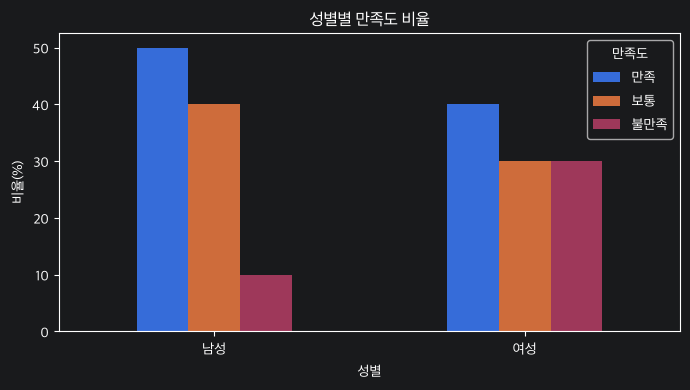

In [14]:
# 셀 목적: 성별별 행 합계로 각 셀을 나누어 만족도 비율을 계산하고 막대그래프로 비교한다.
# 해석 포인트: 빈도만 비교할 때 생길 수 있는 집단 크기 영향을 제거해 분포 차이의 방향을 읽는다.
satisfaction_ratio = contingency_table.div(  # 각 성별 내부의 만족도 비율을 백분율로 계산
    contingency_table.sum(axis=1),  # 각 성별 행의 전체 응답자 수를 분모로 전달
    axis=0  # 행 또는 열 기준 계산 방향을 지정
) * 100  # 행별 비율을 백분율 단위로 바꾸며 계산을 마침

print("성별별 만족도 비율(%)")  # 다음 표가 각 성별 내부에서 계산한 만족도 범주별 백분율임을 알리는 제목을 출력
display(satisfaction_ratio.round(1))  # DataFrame 결과를 표 형태로 노트북에 표시

satisfaction_ratio.plot(kind="bar", figsize=(7, 4))  # 성별별 만족도 비율을 그룹 막대그래프로 그림
plt.ylabel("비율(%)")  # 그래프 y축이 나타내는 측정 단위 이름 설정
plt.title("성별별 만족도 비율")  # 그래프가 표현하는 분석 내용을 제목으로 설정
plt.xticks(rotation=0)  # x축 눈금 위치와 집단 이름 또는 글자 회전 설정
plt.legend(title="만족도")  # 범례에 만족도 범주의 의미를 나타낼 제목 설정
plt.tight_layout()  # 그래프 제목과 축 라벨이 겹치지 않도록 여백 자동 조정
plt.show()  # 지금까지 설정한 그래프를 화면에 출력

## 3. Pearson 카이제곱과 우도비 G-test 비교

두 검정은 같은 독립성 가설을 검정하지만 관측 빈도와 기대 빈도의 차이를 측정하는 방식이 다르다.

- Pearson 카이제곱: 제곱 차이를 기대 빈도로 나누어 합한다. 수업의 주 검정으로 사용한다.
- 우도비 G-test: 관측 빈도와 기대 빈도의 로그 우도비를 사용한다.

두 방법을 모두 실행해 결과가 같은 방향인지 비교한다.

In [15]:
# 셀 목적: Pearson 카이제곱과 우도비 G-test를 모두 실행해 독립성 검정 결과를 비교한다.
# 해석 포인트: 후속 기대빈도·잔차·효과크기는 수업의 주 방법인 Pearson χ² 결과를 사용한다.
pearson_chi = stats.chi2_contingency(  # 관측빈도와 기대빈도를 비교하는 Pearson χ² 결과를 계산
    contingency_table,  # 독립성 검정에 관측빈도 교차표 전달
    correction=False  # 2×2 표용 Yates 연속성 보정을 사용하지 않도록 지정
)  # 함수 호출에 전달할 인자 목록을 닫음
likelihood_ratio = stats.chi2_contingency(  # 로그우도 기반 G-test 결과를 계산
    contingency_table,  # 독립성 검정에 관측빈도 교차표 전달
    correction=False,  # 2×2 표용 Yates 연속성 보정을 사용하지 않도록 지정
    lambda_="log-likelihood"  # 로그우도비 통계량을 사용하는 G-test 방식 지정
)  # 함수 호출에 전달할 인자 목록을 닫음

independence_comparison = pd.DataFrame({  # Pearson χ²와 G-test 결과를 비교표로 구성
    "검정 방법": ["Pearson 카이제곱", "우도비 G-test"],  # 적용한 통계검정 방법 이름을 기록
    "검정통계량": [pearson_chi.statistic, likelihood_ratio.statistic],  # 귀무가설 기준에서 벗어난 정도를 나타내는 통계량 기록
    "자유도": [pearson_chi.dof, likelihood_ratio.dof],  # 참조 t·카이제곱 분포의 모양을 결정하는 자유도 기록
    "p-value": [pearson_chi.pvalue, likelihood_ratio.pvalue]  # 귀무가설 아래에서 현재 이상 결과가 나올 확률 기록
})  # 딕셔너리 구성과 함수 호출을 함께 마침
independence_comparison["결론"] = independence_comparison["p-value"].apply(  # 유의수준 0.05 기준의 판정 문구를 추가
    lambda p: "성별과 만족도 관련 있음" if p < 0.05 else "관련성 증거 부족"  # 각 p-value를 받아 0.05 기준의 해석 문구로 변환
)  # 함수 호출에 전달할 인자 목록을 닫음

display(independence_comparison.round(4))  # DataFrame 결과를 표 형태로 노트북에 표시

# 이후 기대 빈도, 잔차, 효과크기는 수업의 주 검정인 Pearson 결과를 사용한다.
chi2 = pearson_chi.statistic  # Pearson 카이제곱 통계량을 후속 계산용 변수에 저장
p_value = pearson_chi.pvalue  # Pearson 카이제곱 검정의 p-value를 저장
dof = pearson_chi.dof  # Pearson 검정의 자유도를 후속 출력용 변수에 저장
expected = pearson_chi.expected_freq  # 독립을 가정한 셀별 기대빈도 배열을 저장

,검정 방법,검정통계량,자유도,p-value,결론
0,Pearson 카이제곱,12.5397,2,0.0019,성별과 만족도 관련 있음
1,우도비 G-test,13.0118,2,0.0015,성별과 만족도 관련 있음


## 4. 기대 빈도로 카이제곱 검정 조건 확인

카이제곱 근사 검정은 기대 빈도가 너무 작으면 불안정할 수 있다. 기대 빈도를 먼저 확인하고 Pearson 카이제곱 결과를 최종 해석한다.

기대 빈도가 작다면 범주를 이론적으로 타당하게 합치거나, 정확검정 또는 Monte Carlo 방법을 검토한다. 기본 Fisher 정확검정은 주로 2×2 표에서 배우므로 현재 2×3 표에는 바로 적용하지 않는다.

In [16]:
# 셀 목적: 성별과 만족도가 독립일 때 예상되는 셀별 기대빈도를 표로 만든다.
# 해석 포인트: 최소 기대빈도가 5 이상인지 확인해 Pearson 카이제곱 근사의 적용 조건을 점검한다.
expected_table = pd.DataFrame(  # 기대빈도 배열에 원래 행·열 이름을 붙여 DataFrame으로 변환
    expected,  # 독립 가정 아래 계산된 기대빈도 배열 전달
    index=contingency_table.index,  # 기대빈도 표에 사용할 행 이름 지정
    columns=contingency_table.columns  # 결과 DataFrame에 사용할 열 이름 지정
)  # 함수 호출에 전달할 인자 목록을 닫음

print("독립을 가정했을 때의 기대 빈도")  # 다음 표가 성별과 만족도의 독립을 가정해 계산한 기대 빈도임을 알리는 제목을 출력
display(expected_table.round(2))  # DataFrame 결과를 표 형태로 노트북에 표시

minimum_expected = expected_table.to_numpy().min()  # 교차표 기대빈도 중 가장 작은 값을 계산
print(f"가장 작은 기대 빈도: {minimum_expected:.2f}")  # 카이제곱 근사 조건을 점검하기 위해 전체 셀 중 가장 작은 기대 빈도를 출력

if minimum_expected >= 5:  # 최소 기대빈도가 카이제곱 근사 기준 5 이상인지 확인
    print("모든 기대 빈도가 5 이상이므로 카이제곱 근사 조건을 충족한다.")  # 최소 기대 빈도가 5 이상일 때 카이제곱 근사 조건을 충족했다는 판정을 출력
else:  # 앞의 조건이 거짓일 때 사용할 대안 처리 시작
    print("기대 빈도가 작은 셀이 있으므로 정확검정이나 범주 재구성을 검토한다.")  # 최소 기대 빈도가 5 미만일 때 정확검정 또는 범주 재구성이 필요하다는 판정을 출력

print(f"Pearson 카이제곱 p-value: {p_value:.4f}")  # 성별과 만족도의 독립성에 대한 Pearson 카이제곱 검정 p-value를 출력

독립을 가정했을 때의 기대 빈도


만족도,만족,보통,불만족
성별,,,
남성,45.0,35.0,20.0
여성,45.0,35.0,20.0


가장 작은 기대 빈도: 20.00
모든 기대 빈도가 5 이상이므로 카이제곱 근사 조건을 충족한다.
Pearson 카이제곱 p-value: 0.0019


## 5. 어떤 범주가 차이를 만들었는지 확인

전체 카이제곱 검정은 두 변수가 관련 있다는 사실만 알려준다. 표준화 잔차로 실제 빈도와 기대 빈도의 차이가 큰 셀을 확인한다.

- 양수: 실제 관측 빈도가 기대 빈도보다 많다.
- 음수: 실제 관측 빈도가 기대 빈도보다 적다.
- 절댓값이 클수록 전체 카이제곱 통계량에 더 크게 기여한다.

In [17]:
# 셀 목적: 각 셀의 관측-기대 차이를 기대빈도의 제곱근으로 나누어 표준화 잔차를 계산한다.
# 해석 포인트: 부호는 기대보다 많고 적은 방향, 절댓값은 전체 χ²에 대한 셀의 기여 정도를 보여준다.
standardized_residuals = (  # 관측빈도와 기대빈도의 차이를 표준오차 단위로 변환
    contingency_table - expected_table  # 각 셀의 관측빈도에서 기대빈도를 빼 잔차 계산
) / (expected_table ** 0.5)  # 관측-기대 차이를 기대빈도 제곱근으로 나누어 표준화

print("표준화 잔차")  # 다음 표가 각 셀의 관측 빈도와 기대 빈도 차이를 나타내는 표준화 잔차임을 알리는 제목을 출력
display(standardized_residuals.round(2))  # DataFrame 결과를 표 형태로 노트북에 표시

표준화 잔차


만족도,만족,보통,불만족
성별,,,
남성,0.75,0.85,-2.24
여성,-0.75,-0.85,2.24


## 6. Cramér's V로 관계 크기 확인

p-value는 관련성 존재 여부를 판단하지만 관계의 크기를 알려주지 않는다. Cramér's V는 0에서 1 사이로 관계 크기를 나타낸다. 크기 해석 기준은 분야와 표의 크기에 따라 달라질 수 있으므로 절대적인 등급으로 단정하지 않는다.

In [18]:
# 셀 목적: 카이제곱 통계량을 표본크기와 교차표 차원으로 보정해 Cramér's V를 계산한다.
# 해석 포인트: p-value가 관계 존재를 판단한다면 V는 0~1 범위에서 관계의 실질적 크기를 나타낸다.
sample_size = contingency_table.to_numpy().sum()  # 교차표에 포함된 전체 응답자 수를 계산
smaller_dimension = min(  # Cramér's V 분모에 사용할 작은 교차표 차원을 계산
    contingency_table.shape[0] - 1,  # 교차표 행 수에서 1을 빼 행 방향 자유도 계산
    contingency_table.shape[1] - 1  # 교차표 열 수에서 1을 빼 열 방향 자유도 계산
)  # 함수 호출에 전달할 인자 목록을 닫음

cramers_v = (chi2 / (sample_size * smaller_dimension)) ** 0.5  # 카이제곱 통계량을 보정해 Cramér's V 효과크기를 계산
print(f"Cramér's V: {cramers_v:.4f}")  # 성별과 만족도 관계의 효과크기를 나타내는 Cramér's V를 출력

Cramér's V: 0.2504


## 7. 분석 결과

- 범주형 자료이므로 KS-test, Shapiro-Wilk, Levene, t-검정은 적용하지 않았다.
- 모든 기대 빈도가 20 이상이어서 카이제곱 근사 검정 조건을 충족했다.
- Pearson 카이제곱 p-value는 0.0019, G-test p-value는 0.0015로 두 방법 모두 성별과 만족도가 관련 있다는 결론을 보였다.
- 수업의 주 방법인 Pearson 카이제곱 결과에 따라 독립이라는 귀무가설을 기각한다.
- 남성의 불만족 비율은 10%, 여성은 30%였고, 불만족 범주의 표준화 잔차 절댓값이 2.24로 가장 컸다.
- Cramér's V는 0.2504로 관계가 유의하더라도 매우 강한 관계라고 단정할 수준은 아니다.
- 이 결과는 성별이 만족도를 직접 결정한다는 인과관계를 뜻하지 않는다.